In [2]:
import pandas as pd
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path().resolve().parents[0]))

from src.data_loader import load_train_data

train = load_train_data()

In [3]:
corr_matrix = train.corr(numeric_only=True)

In [4]:
corr_matrix.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.000000,0.011156,-0.010601,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.050298,-0.005024,...,-0.029643,-0.000477,0.002889,-0.046635,0.001330,0.057044,-0.006242,0.021172,0.000712,-0.021917
MSSubClass,0.011156,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,-0.010601,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,-0.033226,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,-0.028365,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982


In [5]:
saleprice_corr = corr_matrix["SalePrice"].sort_values(ascending=False)

saleprice_corr.head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

In [6]:
saleprice_corr.tail(10)

BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64

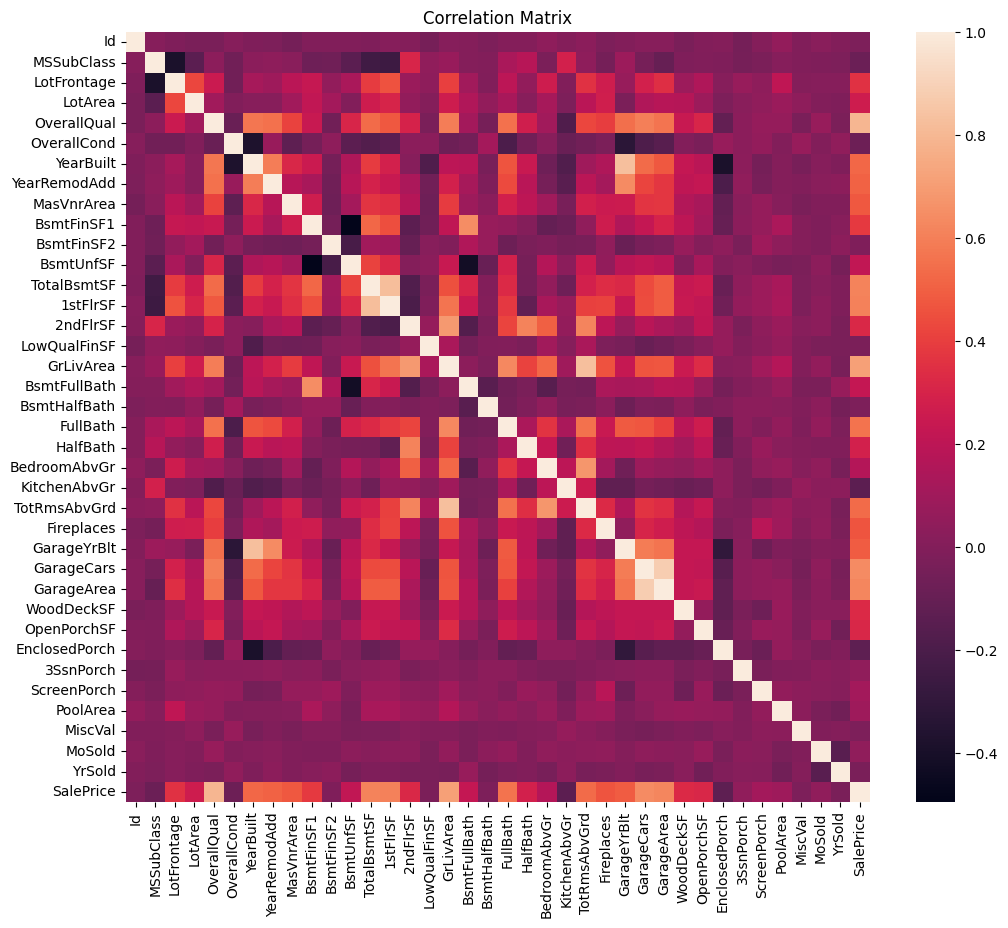

In [7]:
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix)
plt.title("Correlation Matrix")
plt.show()

In [8]:
top_corr_features = saleprice_corr.index[0:10]

top_corr_matrix = train[top_corr_features].corr()

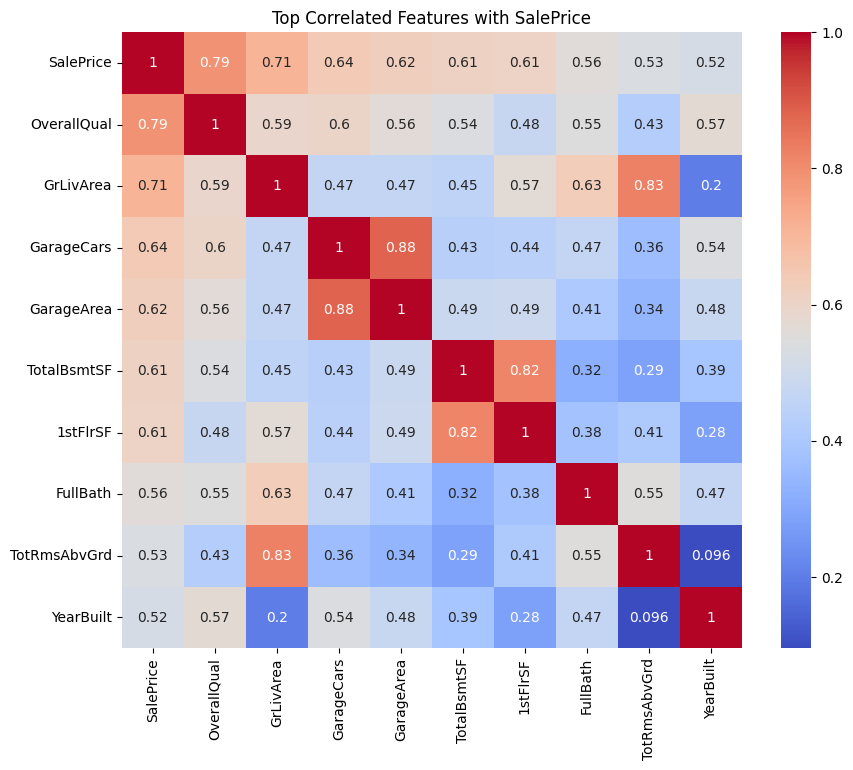

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(top_corr_matrix, annot=True, cmap="coolwarm")
plt.title("Top Correlated Features with SalePrice")
plt.show()

In [10]:
corr_pairs = corr_matrix.abs().unstack().sort_values(ascending=False)

corr_pairs.head(20)

SalePrice      SalePrice        1.0
Id             Id               1.0
ScreenPorch    ScreenPorch      1.0
3SsnPorch      3SsnPorch        1.0
EnclosedPorch  EnclosedPorch    1.0
LowQualFinSF   LowQualFinSF     1.0
MiscVal        MiscVal          1.0
PoolArea       PoolArea         1.0
MSSubClass     MSSubClass       1.0
OpenPorchSF    OpenPorchSF      1.0
TotalBsmtSF    TotalBsmtSF      1.0
LotFrontage    LotFrontage      1.0
GrLivArea      GrLivArea        1.0
1stFlrSF       1stFlrSF         1.0
GarageYrBlt    GarageYrBlt      1.0
MasVnrArea     MasVnrArea       1.0
Fireplaces     Fireplaces       1.0
YearRemodAdd   YearRemodAdd     1.0
YearBuilt      YearBuilt        1.0
TotRmsAbvGrd   TotRmsAbvGrd     1.0
dtype: float64

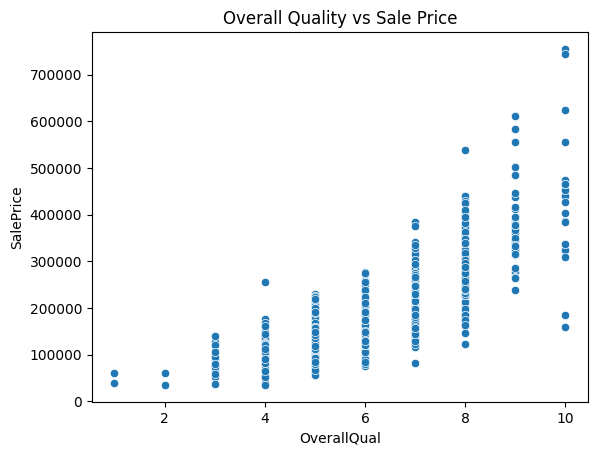

In [11]:
sns.scatterplot(x=train["OverallQual"], y=train["SalePrice"])
plt.title("Overall Quality vs Sale Price")
plt.show()

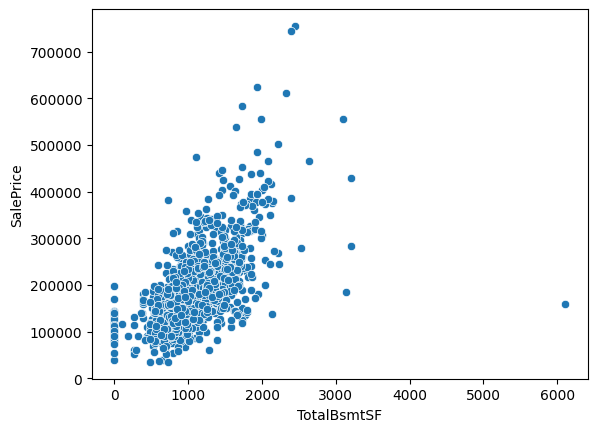

In [12]:
sns.scatterplot(x=train["TotalBsmtSF"], y=train["SalePrice"])
plt.show()

Correlation Insights

- OverallQual is the strongest predictor of house prices
- GrLivArea shows strong positive correlation with price
- GarageCars and GarageArea are highly correlated with each other
- Several size-related variables strongly influence house prices